### 模型二：

In [1]:
import pandas as pd
from pulp import LpMinimize, LpProblem, LpVariable, lpSum, LpBinary,LpStatus
import collections
from itertools import product


file_path = "realdata_v5_2_new.xlsx"  
activities_df = pd.read_excel(file_path, sheet_name="ActivitiesInfo")
classroom_df = pd.read_excel(file_path, sheet_name="ClassroomsInfo")
student_courses_df = pd.read_excel(file_path, sheet_name="StudentsInfo")



In [2]:
df = pd.read_csv("processed_schedule_0.1_notRemote.csv")
df = df[(df["Week"] == 1) & (df["Time_slot"] == 2)]

df

,Week,Time_slot,subject_candidates
1,1,2,"{16, 18, 40, 5}"


In [3]:
courses = student_courses_df["Course_ID"]
courses = set([int(num) for row in courses for num in row.split(', ')])

classrooms = classroom_df["Classroom_ID"]
classrooms = set(int(row) for row in classrooms)

activity_types = activities_df["Activity_Type"]
activity_types = set(activity_types)

In [4]:

Pc = [row["Classroom_ID"] for _, row in classroom_df.iterrows() if row["Has_Computers"] == 1]
Ysi = {(row["Course_ID"], row["Activity_Type"]): 1 for _, row in activities_df.iterrows()}
Gs = {row["Course_ID"]: 1 for _, row in activities_df.iterrows() if row["Requires_Separation"] == 1}
Cs = {row["Course_ID"]: 1 for _, row in activities_df.iterrows() if row["Requires_Computers"] == 1}
Ts = {row["Course_ID"]: 1 for _, row in activities_df.iterrows() if row["Requires_Tables"] == 1}
Tc = {row["Classroom_ID"]: 1 for _, row in classroom_df.iterrows() if row["Has_Tables"] == 1}
Act = {(row["Classroom_ID"], int(w), int(t)): 1 for _, row in classroom_df.iterrows() for w in row["Available_Weeks"].split(', ') for t in row["Time_Slot"].split(', ')} #
Ic = {row["Classroom_ID"]: 1 for _, row in classroom_df.iterrows() if row["Is_Isolated"] == 1}
Ns = {row["Course_ID"]: row["Num_Students"] for _, row in activities_df.iterrows()}
Msg = collections.defaultdict(int)
for _, row in student_courses_df.iterrows():
    class_id = row["Class_ID"]
    course_ids = list(map(int, str(row["Course_ID"]).split(', ')))  
    for course_id in course_ids:
        Msg[(course_id, class_id)] += 1  

            
class_courses = collections.defaultdict(set)
for (course, class_id), _ in Msg.items():
    class_courses[course].add(class_id)

Capacity = {row["Classroom_ID"]: row["Capacity"] for _, row in classroom_df.iterrows()}
Occupancy_rate = {1: 1, 2: 0.9, 3: 0}
CAPci = {(c, i): int(Capacity[c] * Occupancy_rate[i]) for c, i in product(classrooms, activity_types)}

In [5]:
import csv
with open("results-两个变化叠加.csv", "w", newline="", encoding="utf-8") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Week", "Time_slot", "subject_candidates", "result","value"])

results = []

In [6]:
from itertools import product
import pulp
import time
# Define solver parameter combinations (example)
solver_params = {
    "timeLimit": [5, 10],    # Time limit (seconds)
    "gapRel": [0.01, 0.05],  # Relative gap tolerance
    "threads": [1, 4],       # Number of threads
    "cuts": ["on", "off"],   # Cutting planes
}
param_combinations = list(product(*solver_params.values()))

solver_results = []

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


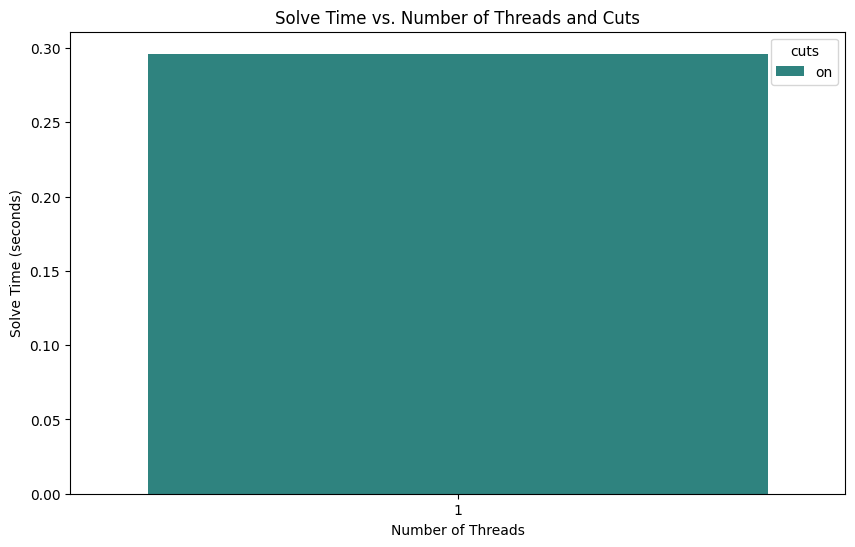

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


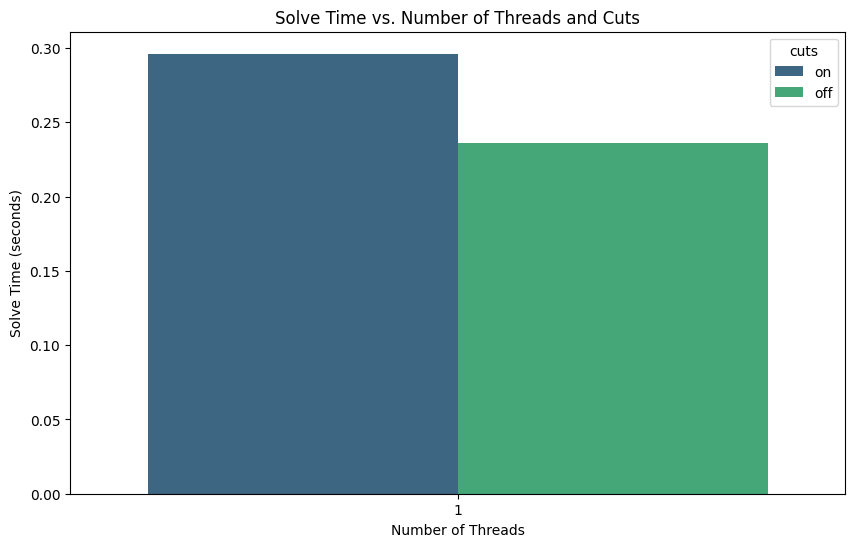

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


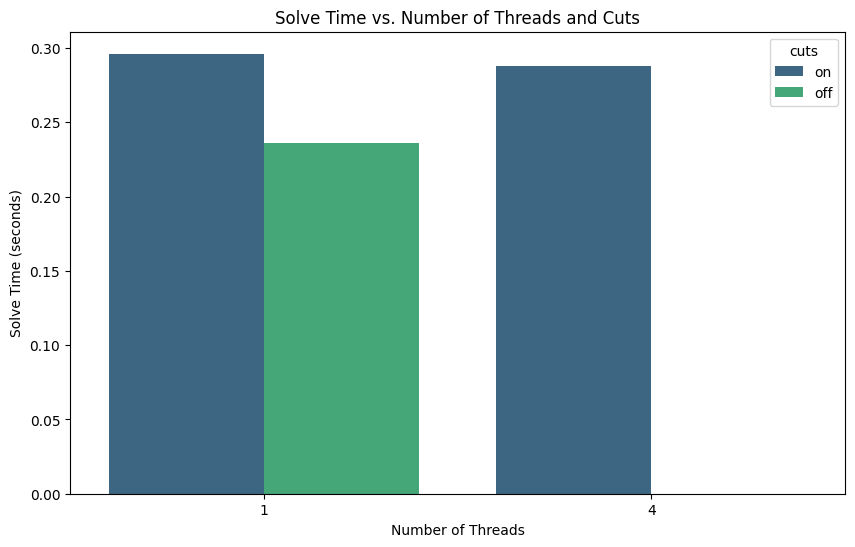

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


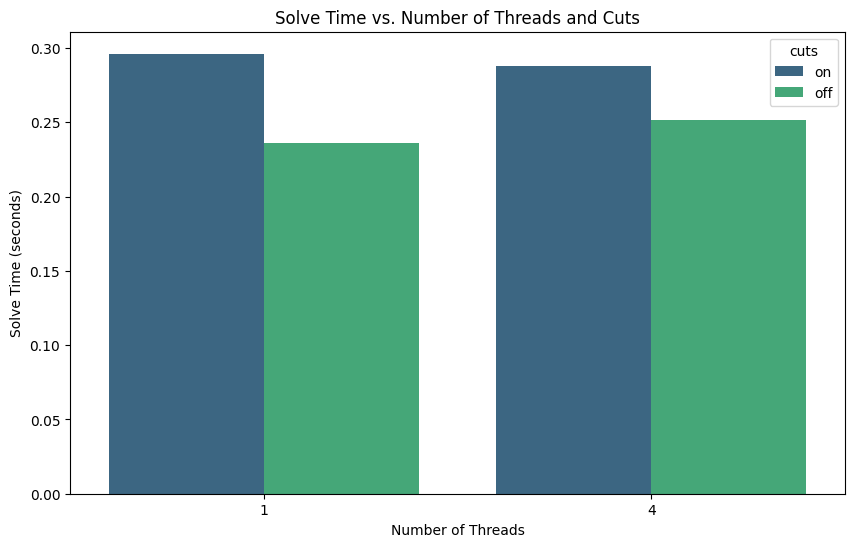

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


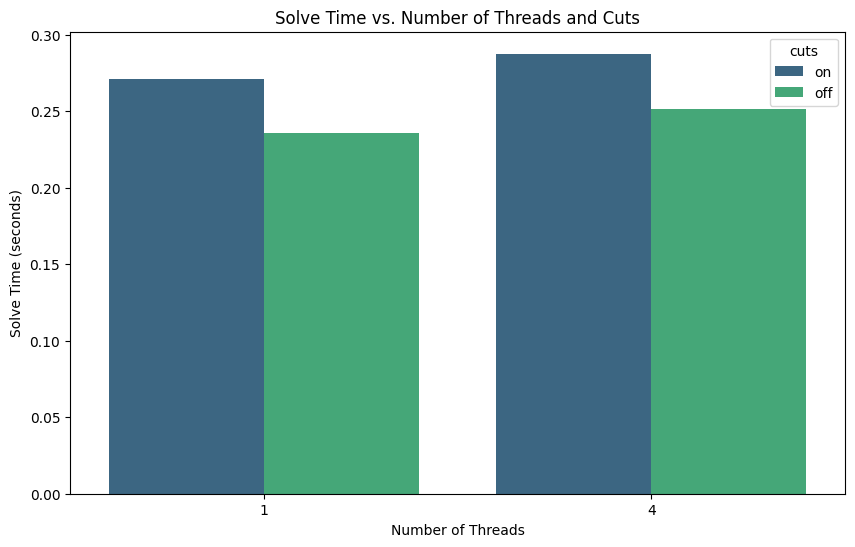

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


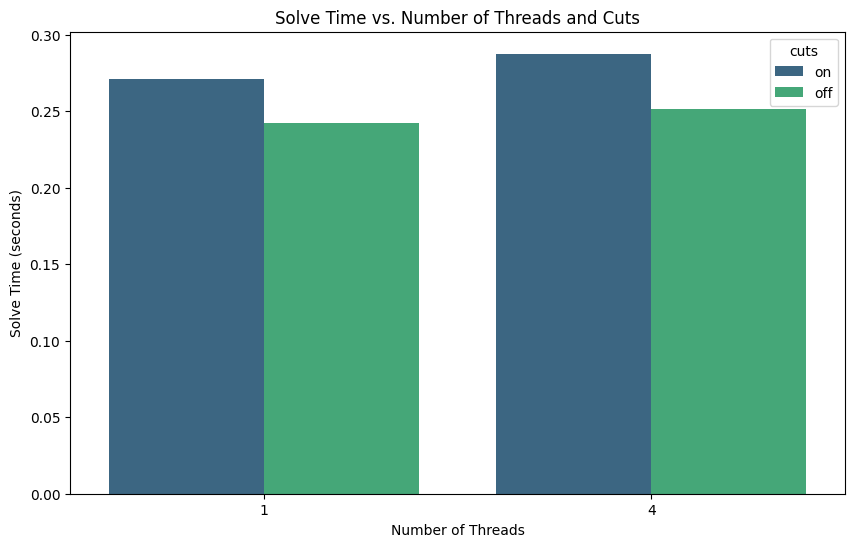

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


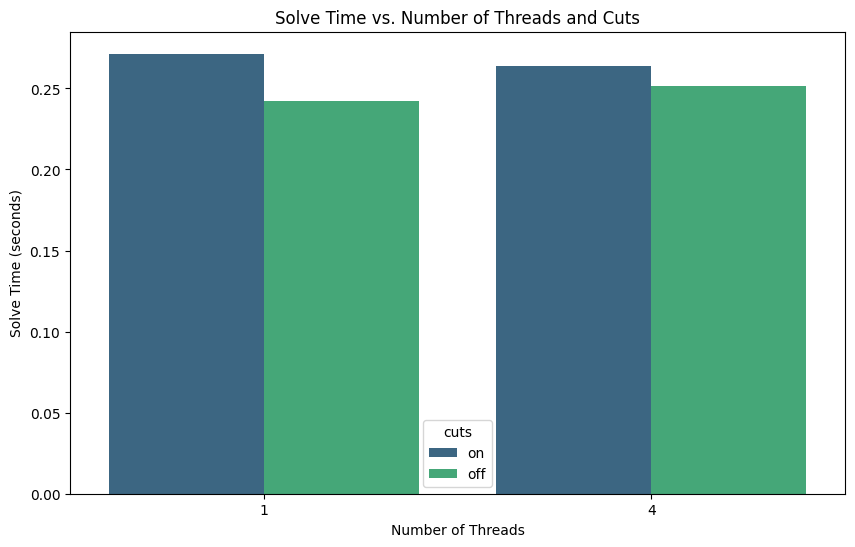

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


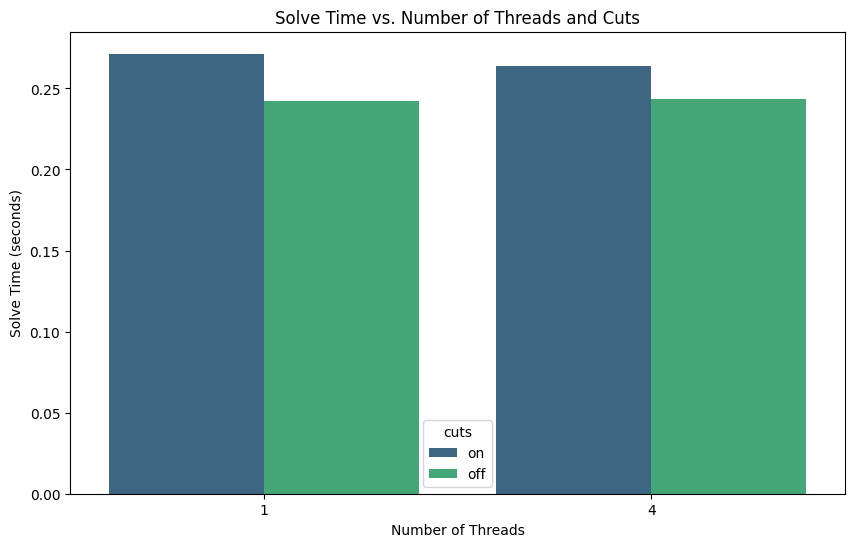

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


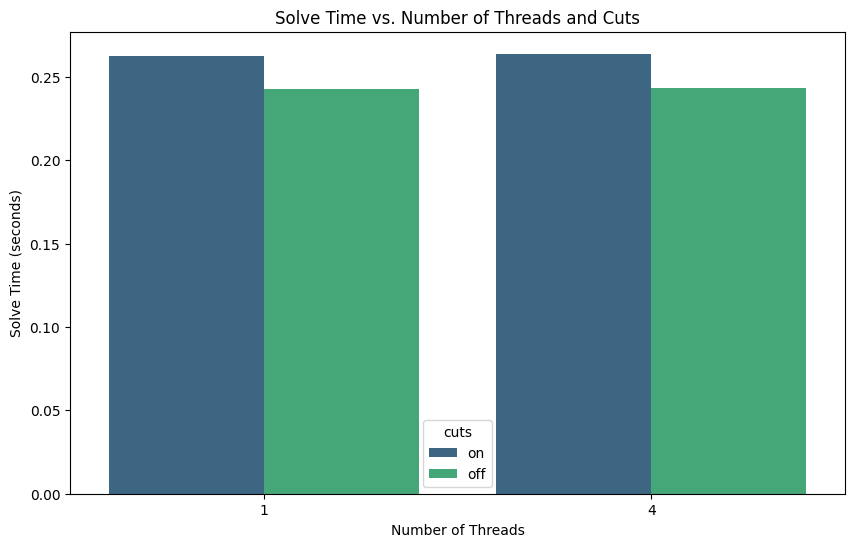

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


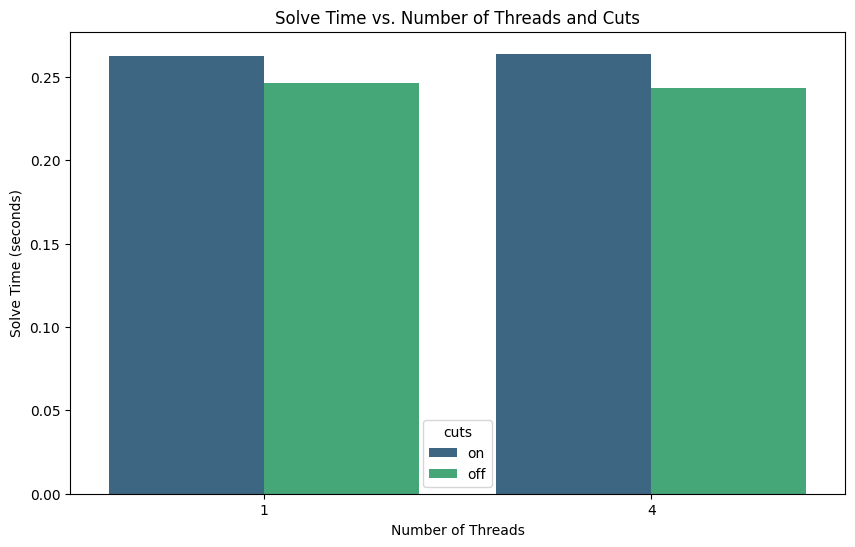

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


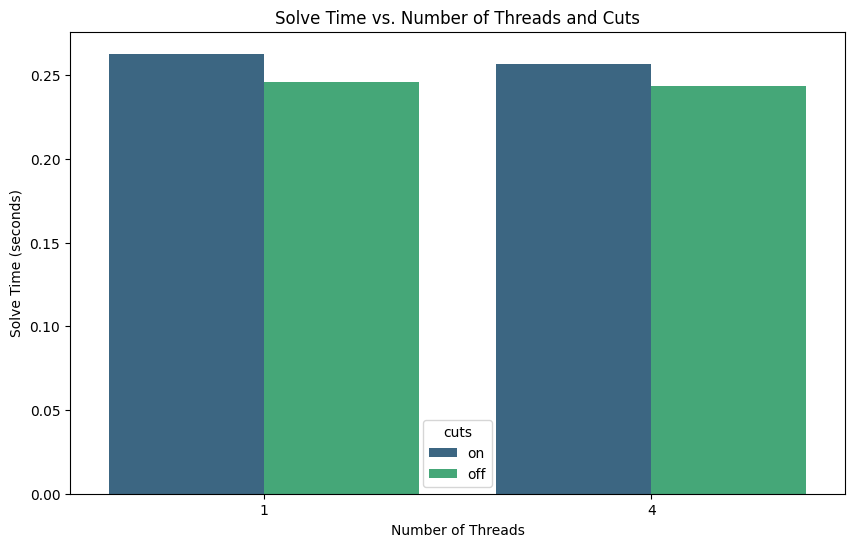

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


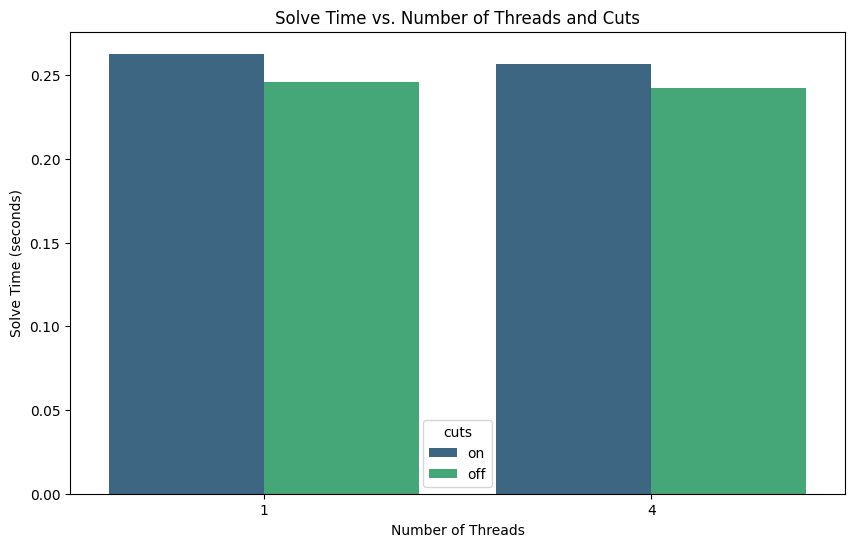

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


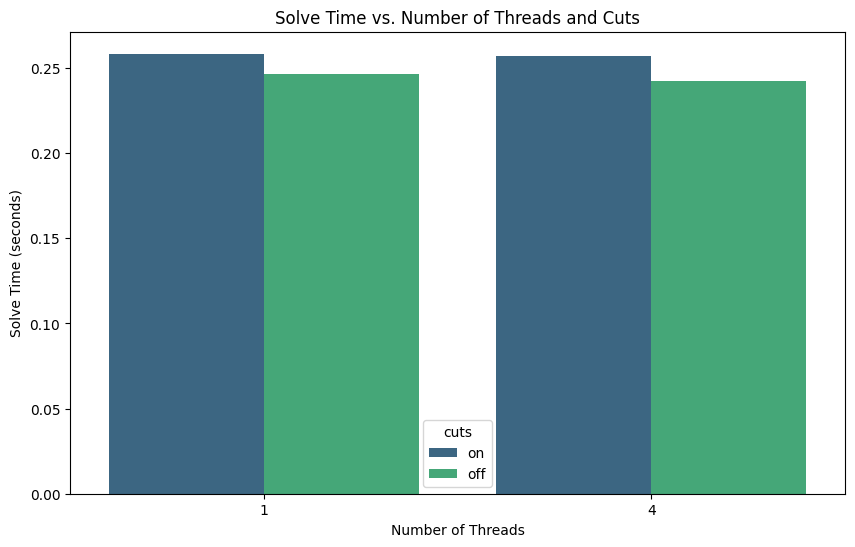

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


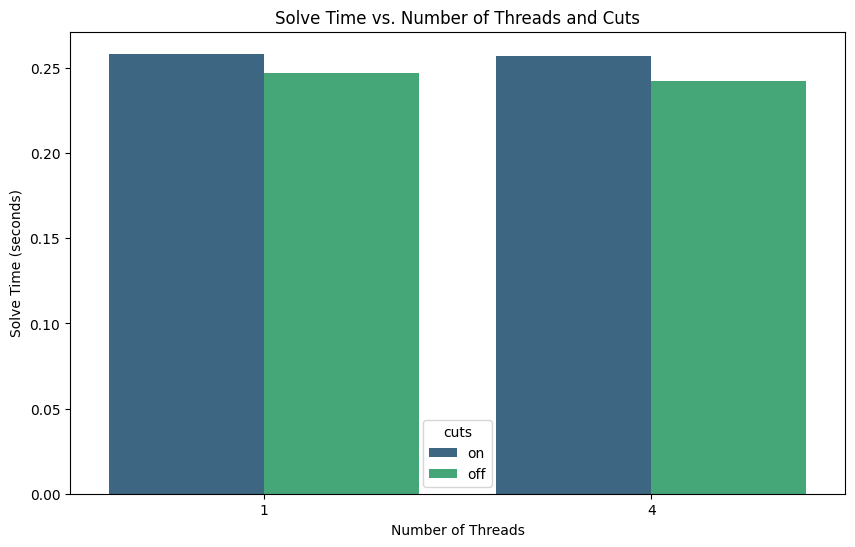

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


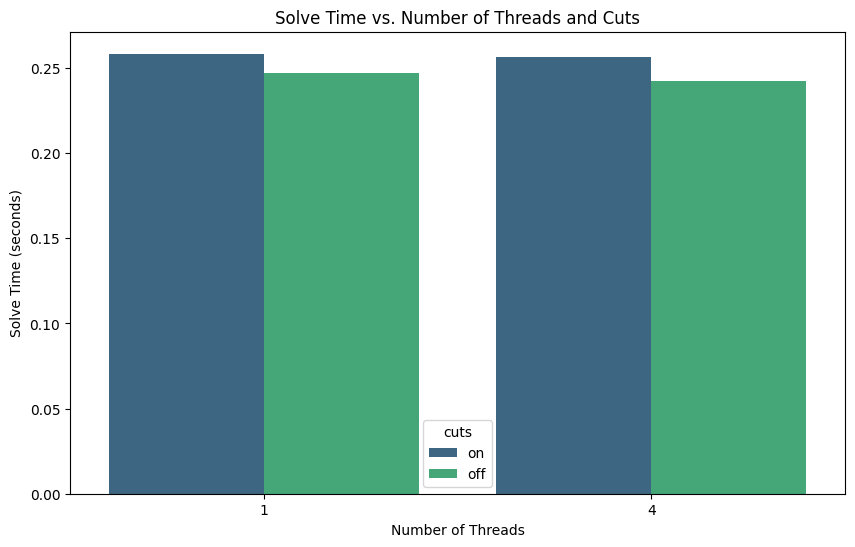

Week: 1
Time Slot: 2
优化状态: Optimal
目标函数值: 11.0


/var/folders/xg/6886p3rj5kb44k2smttjctf80000gn/T/ipykernel_7534/331475772.py:154: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


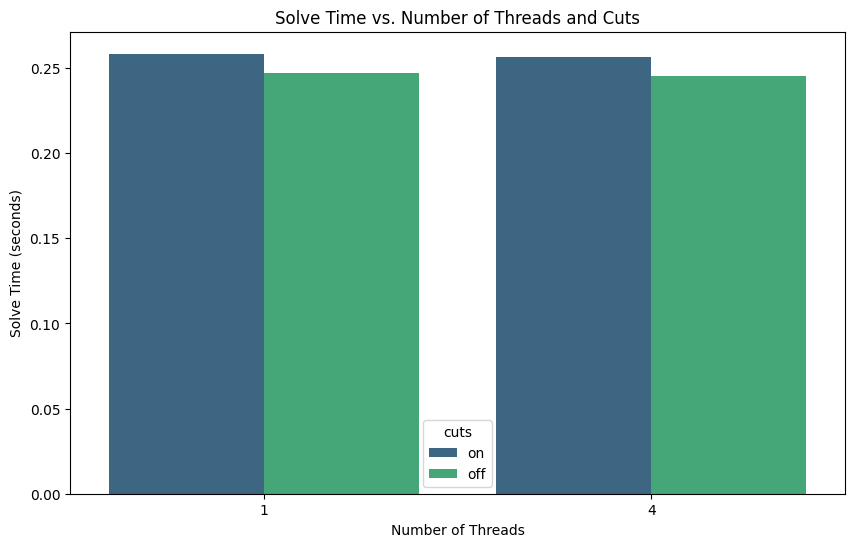

In [7]:

for params in param_combinations:
    param_dict = dict(zip(solver_params.keys(), params))
    # set solver
    solver = pulp.PULP_CBC_CMD(
        timeLimit=param_dict["timeLimit"],
        gapRel=param_dict["gapRel"],
        threads=param_dict["threads"],
        cuts=param_dict["cuts"],
        msg=False  # Turn off solver output

    )
    
    week = df.iloc[0]["Week"]
    time_slot = df.iloc[0]["Time_slot"]
    subjects = df["subject_candidates"].tolist()
    subjects = [int(i.strip('{}')) for i in subjects[0].split(', ')]
   
    model = LpProblem(name="classroom_assignment", sense=LpMinimize)

    z = {(c, s): LpVariable(f"z_{c}_{s}", cat=LpBinary) for c in classrooms for s in subjects}
    w = {(c, s, g): LpVariable(f"w_{c}_{s}_{g}", cat=LpBinary) for c in classrooms for s in subjects for g in class_courses[s]}

    eta = {(s): LpVariable(f"eta_{s}", lowBound=0) for s in subjects}
    lamda = 20
    beta = 10
    
    z_v = {(s): LpVariable(f"z_v_{s}", cat=LpBinary) for s in subjects}

    model += (
    lpSum(z[c, s] for c in classrooms for s in subjects) + 
    lamda * lpSum(eta[s] for s in subjects) +
    beta * lpSum(z_v[s] for s in subjects),
    "Minimize_Classroom_Usage"
)
    # A.13 - make sure each classroom has enough capacity
    for s in subjects:
        model += lpSum(z[c, s] * sum(CAPci.get((c, i), 0) * Ysi.get((s, i), 0) for i in activity_types) for c in classrooms)  + eta[s]>= Ns[s]* (1 - z_v[s]), f"Capacity_Constraint_{s}"
        model +=  eta[s] <= 0.15 * Ns[s] 


    # A.14 - make sure each classroom has enough capacity
    for s in subjects:
        if Ts.get(s, 0) == 1 :
            for g in class_courses[s]:
                model +=  lpSum(w[c, s, g] * sum(CAPci.get((c, i), 0) * Ysi.get((s, i), 0) for i in activity_types) for c in classrooms)>= Msg.get((s, g), 0)* (1- z_v[s]), f"Classroom_Capacity_{s}_{g}"

    # A.15 - classroom can only be assigned to one subject
    for c in classrooms:
        model += lpSum(z[c, s] for s in subjects) <= 1, f"Single_Assignment_{c}"

    # add virtual subject
    for s in subjects:
        for c in classrooms:
            model += z_v[s]+ z[c, s] <= 1, f"Vitural_Assignment_{s}_{c}"
    
    # A.16 - only available classrooms can be assigned
    for c in classrooms:
        for s in subjects:
            model += z[c, s] <= Act.get((c, week, time_slot), 0), f"Classroom_Availability_{c}_{s}"

    # A.17 - consistency constraints
    for c in classrooms:
        for s in subjects:
            if Gs.get(s, 0) == 1:
                for g in class_courses[s]:
                    model += z[c, s] >= w[c, s, g], f"Consistency_1_{c}_{s}_{g}"
                # 补充约束
                    model += w[c, s, g] <= 1-z_v[s], f"Consistency_1_zv_{c}_{s}_{g}"

    # A.18 - consistency constraints
    for c in classrooms:
        for s in subjects:
            if Gs.get(s, 0) == 1:
                model += z[c, s] <= lpSum(w[c, s, g] for g in class_courses[s]), f"Consistency_2_{c}_{s}"

    # # # A.19 - make sure no two groups of the same subject are assigned to the same classroom
    for c in classrooms:
        for s in subjects:
            if Gs.get(s, 0) == 1:
                for g1 in class_courses[s]:
                    for g2 in class_courses[s]:
                        if g1 != g2:
                            model += w[c, s, g1] + w[c, s, g2] <= 1, f"No_Shared_Classroom_{c}_{s}_{g1}_{g2}"

    # # A.20 - requirement for computers
    for c in classrooms:
        for s in subjects:
            if Cs.get(s, 0) == 1 and c not in Pc:
                model += z[c, s] == 0, f"Computer_Requirement_{c}_{s}"

    # # A.21 - requirement for tables
    for c in classrooms:
        for s in subjects:
            if Ts.get(s, 0) == 1 and Tc.get(c, 0) == 0:  # 课程需要桌子但教室没有
                model += z[c, s] == 0, f"Table_Requirement_{c}_{s}"


    # A.22 - isolation requirement
    for c in classrooms:
        for s in subjects:
            if Ic.get(c, 0) == 1:
                model += lpSum(z[c_prime, s] for c_prime in classrooms if c_prime != c) <= (1 - z[c, s]) * len(classrooms), f"Isolation_Requirement_{c}_{s}"



    # 3. mark the start time
    start_time = time.time()
    model.solve(solver)
    solve_time = time.time() - start_time

    # 4. print the results
    print("Week:", week)
    print("Time Slot:", time_slot)
    print("优化状态:", LpStatus[model.status])
    value = model.objective.value()
    print("目标函数值:", value)
    if model.status == 1:  # 仅当找到可行解时输出分配详情
        solver_results.append({
        **param_dict,
        "objective": model.objective.value(),
        "status": "Optimal",
        "solve_time": model.solutionTime,
        "gap": solver.actualRelGap if hasattr(solver, "actualRelGap") else None,
        })
    else:
        solver_results.append({
            **param_dict,
            "solve_time": solve_time,
            "objective": None,
            "status": "Infeasible"
        })
    
    df_solver = pd.DataFrame(solver_results)
        
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=df_solver,
        x="threads",
        y="solve_time",
        hue="cuts",
        ci=None,
        palette="viridis"
    )
    plt.title("Solve Time vs. Number of Threads and Cuts")
    plt.xlabel("Number of Threads")
    plt.ylabel("Solve Time (seconds)")
    plt.show()

          



In [14]:
# 转换为 DataFrame
df_solver = pd.DataFrame(solver_results)

# 过滤可行解并排序（按求解时间和目标函数值）
df_feasible = df_solver[df_solver["status"] == "Optimal"].sort_values(
    by=["solve_time", "objective"], ascending=[True, True]
)

# 显示最优参数组合
best_params = df_feasible.iloc[0]
print("最优参数组合：")
print(best_params[["timeLimit", "gapRel", "threads", "cuts", "solve_time", "objective"]])

最优参数组合：
timeLimit            5
gapRel            0.05
threads              4
cuts               off
solve_time    0.235685
objective         11.0
Name: 7, dtype: object


In [13]:
print (df_solver)

    timeLimit  gapRel  threads cuts  objective   status  solve_time   gap
0           5    0.01        1   on       11.0  Optimal    0.296215  None
1           5    0.01        1  off       11.0  Optimal    0.235897  None
2           5    0.01        4   on       11.0  Optimal    0.287640  None
3           5    0.01        4  off       11.0  Optimal    0.251523  None
4           5    0.05        1   on       11.0  Optimal    0.246569  None
5           5    0.05        1  off       11.0  Optimal    0.249089  None
6           5    0.05        4   on       11.0  Optimal    0.240246  None
7           5    0.05        4  off       11.0  Optimal    0.235685  None
8          10    0.01        1   on       11.0  Optimal    0.245706  None
9          10    0.01        1  off       11.0  Optimal    0.253605  None
10         10    0.01        4   on       11.0  Optimal    0.242783  None
11         10    0.01        4  off       11.0  Optimal    0.240298  None
12         10    0.05        1   on   

In [15]:
# df_solver 输出到csv
df_solver.to_csv("df_solver.csv", index=False)
